In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

df = pd.read_csv("/content/CC GENERAL.csv")


In [ ]:
df.head()
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
# Data Preprocessing
# Customer Id not useful
df.drop(columns=['CUST_ID'], inplace=True)
# Check for NULL values
print("Null values:\n", df.isnull().sum())

# Drop NULL values if any
df.dropna(inplace=True)

Null values:
 BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


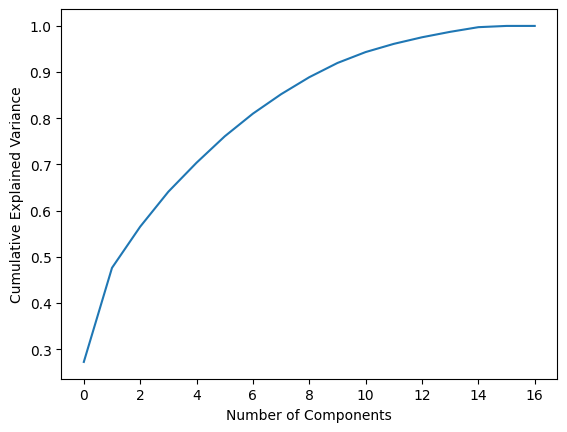

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()


In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print("Optimal number of PCA components:", n_components)


Optimal number of PCA components: 12


In [ ]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


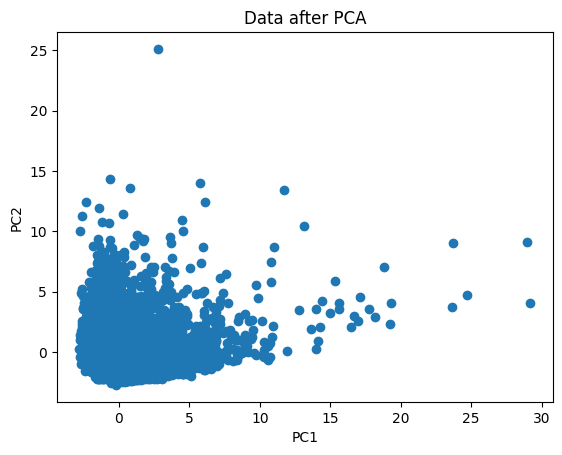

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data after PCA")
plt.show()


In [ ]:
wcss = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))


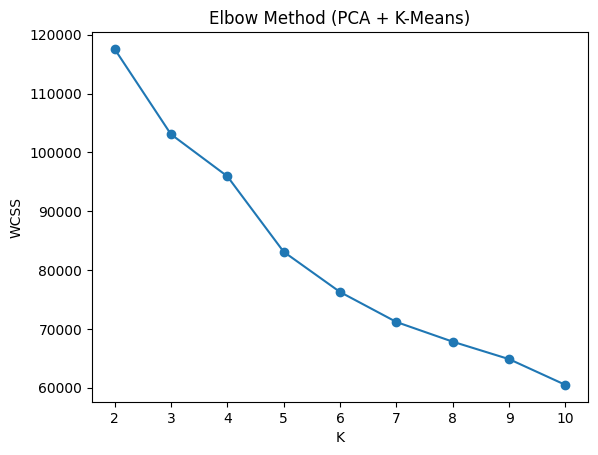

In [ ]:
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method (PCA + K-Means)")
plt.show()


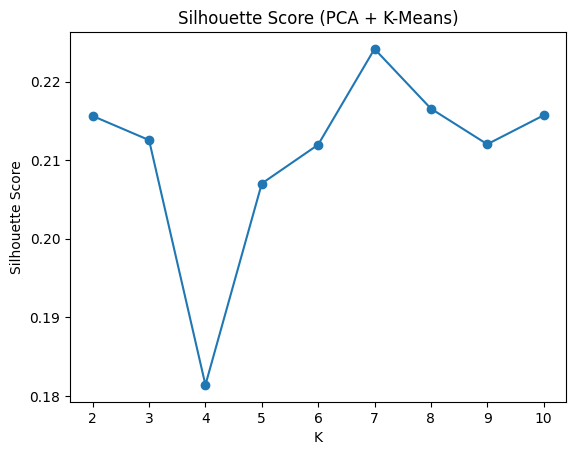

In [ ]:
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (PCA + K-Means)")
plt.show()


In [ ]:
best_k_silhouette = K[np.argmax(sil_scores)]
print("Best K (Silhouette):", best_k_silhouette)

Best K (Silhouette): 7


In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

# ------------------------------
# Automatic K selection using Elbow Method
# ------------------------------

knee = KneeLocator(
    K,
    wcss,
    curve='convex',
    direction='decreasing'
)

best_k_elbow = knee.elbow
print("Best K (Elbow):", best_k_elbow)


Best K (Elbow): 5


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df['Cluster'] = clusters


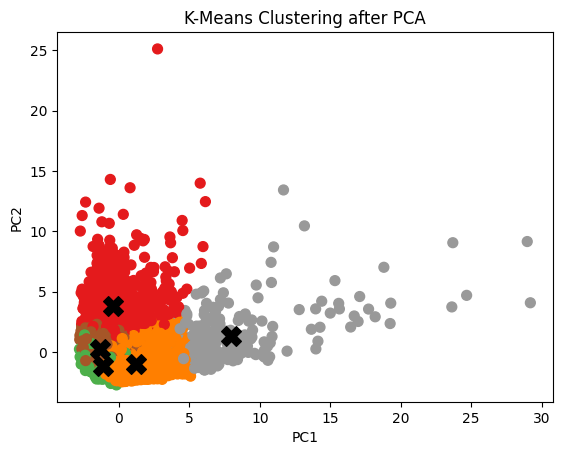

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='Set1', s=50)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='black', s=200, marker='X')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering after PCA")
plt.show()


In [ ]:
new_customer = pd.DataFrame({
    'BALANCE': [500],
    'BALANCE_FREQUENCY': [1.0],
    'PURCHASES': [200],
    'ONEOFF_PURCHASES': [150],
    'INSTALLMENTS_PURCHASES': [50],
    'CASH_ADVANCE': [0],
    'PURCHASES_FREQUENCY': [0.6],
    'ONEOFF_PURCHASES_FREQUENCY': [0.4],
    'PURCHASES_INSTALLMENTS_FREQUENCY': [0.3],
    'CASH_ADVANCE_FREQUENCY': [0],
    'CASH_ADVANCE_TRX': [0],
    'PURCHASES_TRX': [10],
    'CREDIT_LIMIT': [3000],
    'PAYMENTS': [400],
    'MINIMUM_PAYMENTS': [200],
    'PRC_FULL_PAYMENT': [0.5],
    'TENURE': [12]
})

new_scaled = scaler.transform(new_customer)
new_pca = pca.transform(new_scaled)
kmeans.predict(new_pca)


array([2], dtype=int32)